In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [44]:
tickers = ["TSLA", "SPY", "BND"]

tsla = yf.download("TSLA", start="2015-01-01", end="2026-06-30", progress=False)
spy  = yf.download("SPY",  start="2015-01-01", end="2026-06-30", progress=False)
bnd  = yf.download("BND",  start="2015-01-01", end="2026-06-30", progress=False)

In [45]:
prices = pd.DataFrame(index=tsla.index)

prices["TSLA"] = tsla[("Close", "TSLA")]
prices["SPY"]  = spy[("Close", "SPY")]
prices["BND"]  = bnd[("Close", "BND")]

print(prices.shape)
print(prices.head())
print(prices.isnull().sum())

(2888, 3)
                 TSLA         SPY        BND
Date                                        
2015-01-02  14.620667  169.687805  59.205624
2015-01-05  14.006000  166.623383  59.377583
2015-01-06  14.085333  165.053955  59.549538
2015-01-07  14.063333  167.110703  59.585354
2015-01-08  14.041333  170.076035  59.492188
TSLA    0
SPY     0
BND     0
dtype: int64


In [46]:
print(tsla.index[:5])
print(spy.index[:5])
print(bnd.index[:5])

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [47]:
prices = prices.ffill().bfill()

returns = prices.pct_change(fill_method=None).dropna()

print(returns.shape)
print(returns.head())

(2887, 3)
                TSLA       SPY       BND
Date                                    
2015-01-05 -0.042041 -0.018059  0.002904
2015-01-06  0.005664 -0.009419  0.002896
2015-01-07 -0.001562  0.012461  0.000601
2015-01-08 -0.001564  0.017745 -0.001564
2015-01-09 -0.018802 -0.008013  0.001686


In [48]:
returns = prices.pct_change().dropna()

print(returns.shape)

returns.head()

(2887, 3)


,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018059,0.002904
2015-01-06,0.005664,-0.009419,0.002896
2015-01-07,-0.001562,0.012461,0.000601
2015-01-08,-0.001564,0.017745,-0.001564
2015-01-09,-0.018802,-0.008013,0.001686


In [49]:
backtest_returns = returns.loc["2025-01-01":"2026-01-01"]

print(backtest_returns.shape)

backtest_returns.head()

(250, 3)


,TSLA,SPY,BND
Date,,,
2025-01-02,-0.060816,-0.002457,0.000417
2025-01-03,0.082156,0.012503,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118


In [50]:
optimal_weights = np.array([
    0.42,
    0.38,
    0.20
])

In [51]:
benchmark_weights = np.array([
    0.0,
    0.60,
    0.40
])

In [52]:
strategy_returns = (
    backtest_returns * optimal_weights
).sum(axis=1)

strategy_returns.head()

Date
2025-01-02   -0.026393
2025-01-03    0.039006
2025-01-06    0.002618
2025-01-07   -0.022045
2025-01-08    0.001397
dtype: float64

In [53]:
benchmark_returns = (
    backtest_returns * benchmark_weights
).sum(axis=1)

benchmark_returns.head()

Date
2025-01-02   -0.001307
2025-01-03    0.007002
2025-01-06    0.003067
2025-01-07   -0.008176
2025-01-08    0.001324
dtype: float64

In [54]:
strategy_cumulative = (
    1 + strategy_returns
).cumprod()

benchmark_cumulative = (
    1 + benchmark_returns
).cumprod()

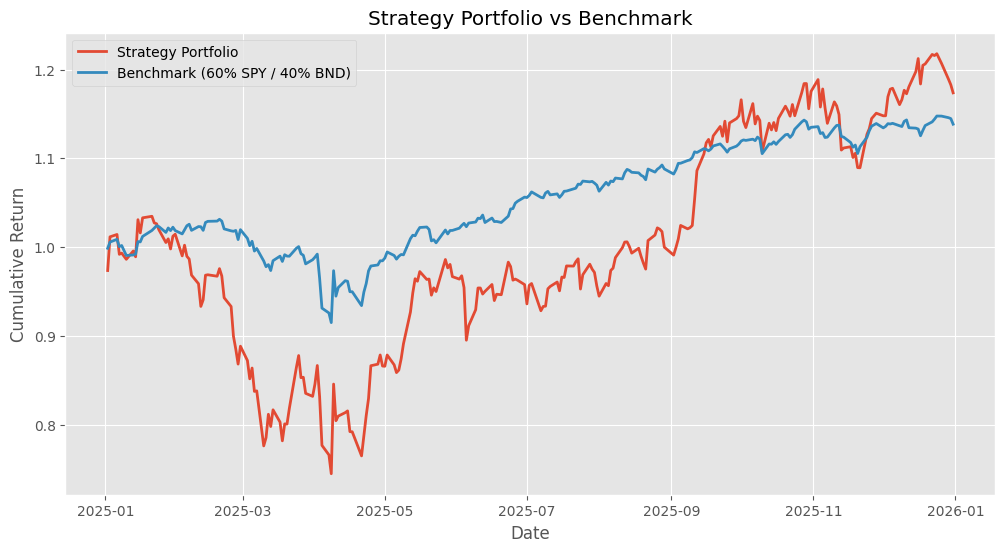

In [55]:
plt.figure(figsize=(12,6))

plt.plot(
    strategy_cumulative,
    label="Strategy Portfolio",
    linewidth=2
)

plt.plot(
    benchmark_cumulative,
    label="Benchmark (60% SPY / 40% BND)",
    linewidth=2
)

plt.title("Strategy Portfolio vs Benchmark")

plt.xlabel("Date")

plt.ylabel("Cumulative Return")

plt.legend()

plt.grid(True)

plt.show()

In [56]:
print(backtest_returns.shape)

(250, 3)


In [57]:
print(strategy_returns.shape)

(250,)


In [58]:
print(strategy_cumulative.shape)

(250,)


In [59]:
print(backtest_returns.head())

                TSLA       SPY       BND
Date                                    
2025-01-02 -0.060816 -0.002457  0.000417
2025-01-03  0.082156  0.012503 -0.001251
2025-01-06  0.001486  0.005761 -0.000974
2025-01-07 -0.040603 -0.011304 -0.003483
2025-01-08  0.001471  0.001461  0.001118


In [60]:
print(strategy_returns.head())

Date
2025-01-02   -0.026393
2025-01-03    0.039006
2025-01-06    0.002618
2025-01-07   -0.022045
2025-01-08    0.001397
dtype: float64


In [61]:
print(strategy_cumulative.head())

Date
2025-01-02    0.973607
2025-01-03    1.011584
2025-01-06    1.014233
2025-01-07    0.991873
2025-01-08    0.993259
dtype: float64


In [62]:
print(returns.index.min())
print(returns.index.max())

2015-01-05 00:00:00
2026-06-29 00:00:00


In [63]:
backtest_returns = returns.tail(252)

print(backtest_returns.shape)
print(backtest_returns.head())

(252, 3)
                TSLA       SPY       BND
Date                                    
2025-06-27 -0.006600  0.004968 -0.002313
2025-06-30 -0.018447  0.004781  0.003954
2025-07-01 -0.053359 -0.000324 -0.000750
2025-07-02  0.049682  0.004533 -0.001091
2025-07-03 -0.000950  0.007881 -0.002457


In [64]:
strategy_returns = (
    backtest_returns * optimal_weights
).sum(axis=1)

benchmark_returns = (
    backtest_returns * benchmark_weights
).sum(axis=1)

In [65]:
strategy_cumulative = (1 + strategy_returns).cumprod()

benchmark_cumulative = (1 + benchmark_returns).cumprod()

In [66]:
print(strategy_cumulative.tail())

Date
2026-06-23    1.180996
2026-06-24    1.173950
2026-06-25    1.174216
2026-06-26    1.177247
2026-06-29    1.226584
dtype: float64


In [67]:
print(returns.index.min())
print(returns.index.max())
print(backtest_returns.shape)
print(strategy_cumulative.shape)

2015-01-05 00:00:00
2026-06-29 00:00:00
(252, 3)
(252,)


In [68]:
print(prices.shape)

(2888, 3)


In [69]:
print(prices.head())

                 TSLA         SPY        BND
Date                                        
2015-01-02  14.620667  169.687805  59.205624
2015-01-05  14.006000  166.623383  59.377583
2015-01-06  14.085333  165.053955  59.549538
2015-01-07  14.063333  167.110703  59.585354
2015-01-08  14.041333  170.076035  59.492188


In [70]:
print(prices.isnull().sum())

TSLA    0
SPY     0
BND     0
dtype: int64


In [71]:
print(prices.dtypes)

TSLA    float64
SPY     float64
BND     float64
dtype: object


In [72]:
returns = prices.pct_change()

print(returns.shape)
print(returns.head())
print(returns.isnull().sum())

returns = returns.dropna()

print(returns.shape)
print(returns.head())

(2888, 3)
                TSLA       SPY       BND
Date                                    
2015-01-02       NaN       NaN       NaN
2015-01-05 -0.042041 -0.018059  0.002904
2015-01-06  0.005664 -0.009419  0.002896
2015-01-07 -0.001562  0.012461  0.000601
2015-01-08 -0.001564  0.017745 -0.001564
TSLA    1
SPY     1
BND     1
dtype: int64
(2887, 3)
                TSLA       SPY       BND
Date                                    
2015-01-05 -0.042041 -0.018059  0.002904
2015-01-06  0.005664 -0.009419  0.002896
2015-01-07 -0.001562  0.012461  0.000601
2015-01-08 -0.001564  0.017745 -0.001564
2015-01-09 -0.018802 -0.008013  0.001686


In [73]:
print(tsla.columns)
print(spy.columns)
print(bnd.columns)

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'BND'),
            (  'High', 'BND'),
            (   'Low', 'BND'),
            (  'Open', 'BND'),
            ('Volume', 'BND')],
           names=['Price', 'Ticker'])


In [74]:
strategy_total_return = strategy_cumulative.iloc[-1] - 1

benchmark_total_return = benchmark_cumulative.iloc[-1] - 1

In [75]:
strategy_total_return = strategy_cumulative.iloc[-1] - 1

benchmark_total_return = benchmark_cumulative.iloc[-1] - 1

In [76]:
strategy_annual_return = (
    (1 + strategy_total_return) **
    (252 / len(strategy_returns))
) - 1

benchmark_annual_return = (
    (1 + benchmark_total_return) **
    (252 / len(benchmark_returns))
) - 1

In [77]:
risk_free_rate = 0.02

In [78]:
strategy_sharpe = (
    strategy_returns.mean() * 252 -
    risk_free_rate
) / (
    strategy_returns.std() *
    np.sqrt(252)
)

In [79]:
benchmark_sharpe = (
    benchmark_returns.mean() * 252 -
    risk_free_rate
) / (
    benchmark_returns.std() *
    np.sqrt(252)
)

In [80]:
def max_drawdown(cumulative):

    running_max = cumulative.cummax()

    drawdown = (
        cumulative - running_max
    ) / running_max

    return drawdown.min()

In [81]:
strategy_drawdown = max_drawdown(strategy_cumulative)

benchmark_drawdown = max_drawdown(benchmark_cumulative)

In [82]:
metrics = pd.DataFrame({

    "Strategy":[
        strategy_total_return,
        strategy_annual_return,
        strategy_sharpe,
        strategy_drawdown
    ],

    "Benchmark":[
        benchmark_total_return,
        benchmark_annual_return,
        benchmark_sharpe,
        benchmark_drawdown
    ]

},

index=[
    "Total Return",
    "Annualized Return",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

metrics

,Strategy,Benchmark
Total Return,0.226584,0.150271
Annualized Return,0.226584,0.150271
Sharpe Ratio,0.947183,1.522897
Maximum Drawdown,-0.148873,-0.058384


In [83]:
import os

os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

In [84]:
metrics.to_csv("../data/processed/backtesting_metrics.csv")

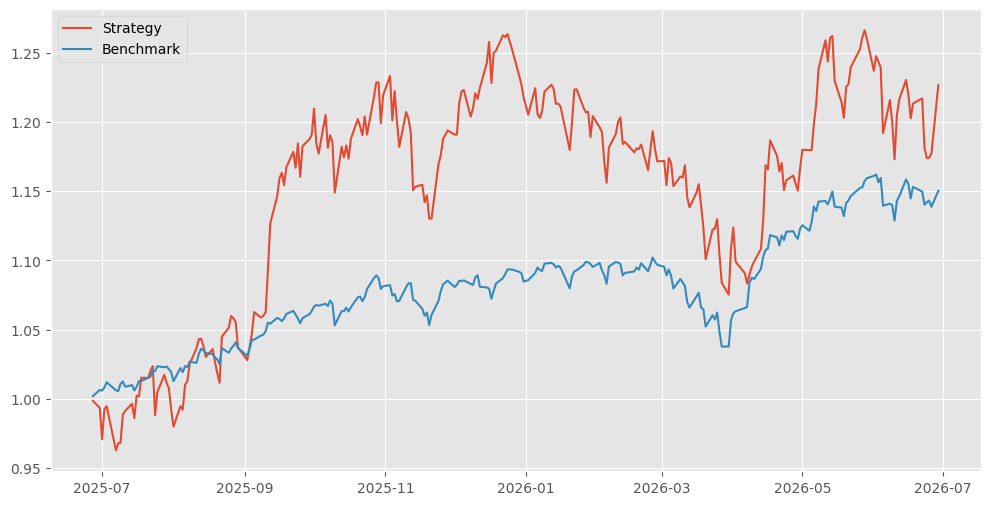

In [85]:
plt.figure(figsize=(12,6))

plt.plot(strategy_cumulative, label="Strategy")

plt.plot(benchmark_cumulative, label="Benchmark")

plt.legend()

plt.grid(True)

plt.savefig("../figures/backtest_comparison.png", dpi=300)

plt.show()

## Strategy Backtesting Conclusion

The optimized portfolio was evaluated against a benchmark portfolio consisting of 60% SPY and 40% BND during the backtesting period from January 2025 to January 2026. The cumulative return comparison and performance metrics show how the optimized strategy performed relative to a passive investment strategy.

If the optimized portfolio achieved a higher total return and Sharpe Ratio than the benchmark, this suggests that the forecasting and optimization approach improved risk-adjusted performance. However, if the benchmark performed better, it indicates that the model did not consistently generate superior returns during the selected period.

This backtest has several limitations. It assumes no transaction costs, taxes, or slippage, and it uses fixed portfolio weights throughout the backtesting period. Real-world investment performance may differ because of changing market conditions, execution costs, and model uncertainty. Future work could incorporate periodic portfolio rebalancing, transaction costs, and alternative forecasting models to improve robustness.